# The Armenian Name Inventor — a neural net learns to speak surname

**Instructor-led practical, chapter 5 (neural networks).** Companion to **L14**
(fundamentals) and **L15** (training).

Every family tree of ChatGPT ends at the same ancestor: the first neural language model
([Bengio et al., 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)) — and
that model was nothing but an **embedding layer plus an MLP**. Exactly the parts we built in
L14 and trained in L15. No attention, no recurrence, no magic.

Today we train that model on **689 Armenian surnames** scraped from the Armenian Wikipedia,
and then ask it to **invent surnames that do not exist**. Along the way, two tools are new:

- **PyTorch** — the deep-learning library the whole field runs on. First contact; every new
  piece gets explained the moment we use it.
- **Weights & Biases (wandb)** — an experiment tracker: a lab notebook that writes itself.
  Today involves ~15 training runs, and nobody can hold 15 loss curves in their head.

Seed is fixed to `509`. Everything runs on a laptop CPU.

In [1]:
import copy
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import wandb

# install into the course venv if missing:  uv pip install torch wandb
SEED = 509
torch.manual_seed(SEED)

# Credentials hygiene: an API key never goes into a notebook (notebooks get committed,
# shared, screenshotted). Ours lives in the repo-root .env (gitignored) as
# WANDB_API_KEY=... - loaded here if present; otherwise wandb falls back to `wandb login`.
env_file = Path("../../.env")
if env_file.exists():
    for line in env_file.read_text(encoding="utf-8").splitlines():
        if line.startswith("WANDB_API_KEY=") and line.split("=", 1)[1].strip():
            os.environ["WANDB_API_KEY"] = line.split("=", 1)[1].strip()

print("torch", torch.__version__, "| wandb", wandb.__version__)

torch 2.9.0+cpu | wandb 0.28.2


## 1. The data: every Armenian surname Wikipedia knows

The Armenian Wikipedia keeps a category
[«Հայկական ազգանուններ»](https://hy.wikipedia.org/wiki/Կատեգորիա:Հայկական_ազգանուններ) with
one page per surname. The prep script `py_src/fetch_surnames.py` pulled every page title,
kept only titles made purely of Armenian letters (dropping disambiguation pages like
«Ազարյան (ազգանուն)» and hyphenated forms), lowercased them so capitals do not double our
alphabet, and pinned the result to `data/surnames_hy.txt` — so this notebook needs no
internet.

In [2]:
names = open("data/surnames_hy.txt", encoding="utf-8").read().split()

lengths = [len(n) for n in names]
print(f"surnames: {len(names)}")
print(f"length min/mean/max: {min(lengths)}/{np.mean(lengths):.1f}/{max(lengths)}")
print(f"ending in -յան: {sum(n.endswith('յան') for n in names)} "
      f"({sum(n.endswith('յան') for n in names)/len(names):.0%})")
print("a few:", ", ".join(names[100:108]))

surnames: 689
length min/mean/max: 5/8.5/14
ending in -յան: 660 (96%)
a few: անանյան, անասյան, անդրանիկյան, անդրեասյան, անդրիասյան, անթառամյան, անջելյան, անտիկյան


## 2. The alphabet, discovered from the data

**Predict first:** how many *distinct characters* do 689 surnames use? (The Armenian
alphabet has 39 letters — do surnames use all of them?)

We do not hardcode the alphabet; we read it off the data. We also add one special character,
`.`, which will mark **the end of a name**. This is not a technicality — it is how the model
will learn that «-յան» is a way to *stop*. Without an end token the net could never finish a
name.

In [3]:
chars = sorted(set("".join(names)))
stoi = {c: i + 1 for i, c in enumerate(chars)}   # letter -> integer code
stoi["."] = 0                                    # the end-of-name token
itos = {i: c for c, i in stoi.items()}           # integer code -> letter
V = len(stoi)

print("alphabet found in the data:", "".join(chars))
print(f"vocabulary size (letters + '.'): {V}")

alphabet found in the data: աբգդեզէթժիլխծկհձղճմյնշոչպջռսվտրցւփքօֆև
vocabulary size (letters + '.'): 39


We hold out 20% of the **names** for validation. By names, not by training windows — windows
cut from the same name are near-duplicates, and splitting them across train/val would leak
(the same trap as ch2's rent model and the [06] evaluation lecture).

In [4]:
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(names))
n_tr = int(0.8 * len(names))
tr_names = [names[i] for i in perm[:n_tr]]
va_names = [names[i] for i in perm[n_tr:]]
tr_set = set(tr_names)
print(f"train names: {len(tr_names)}, val names: {len(va_names)}")

train names: 551, val names: 138


## 3. From characters to model food

**The trap first.** The obvious encoding — Ա=1, Բ=2, … — lies to the model: it says Բ is
"twice" Ա and that Դ is "between" Գ and Ե. None of that is real. Characters are
**categories**, and we learned the honest encoding for categories back in the
feature-engineering lecture: **one-hot** (all zeros, a single 1). We will start from integer
*codes*, but only as row numbers into one-hots — never as quantities.

**The task shape.** The model reads a **context window** of the previous $K$ characters and
predicts the next one. Sliding that window over «պողոսյան» with $K = 3$ (with `.` as
padding/end):

```
. . .  ->  պ          ո ս յ  ->  ա
. . պ  ->  ո          ս յ ա  ->  ն
. պ ո  ->  ղ          յ ա ն  ->  .   <- "now stop"
պ ո ղ  ->  ո  ...
```

One name of length $L$ yields $L{+}1$ training examples. The whole dataset is just these
(context, next-char) pairs.

**Two minutes on tensors,** exactly where we first need them: a `torch.tensor` is a numpy
array that (a) remembers how it was computed, so gradients can flow backward through it
(that is autograd — the machinery running L15's backprop for us), and (b) can live on a GPU.
The two things you always check are `.shape` and `.dtype`.

In [5]:
def build_dataset(name_list, K):
    """Slide a K-wide window over every name; return (contexts X, next-chars Y)."""
    X, Y = [], []
    for n in name_list:
        ctx = [0] * K                      # start: K end-tokens as padding
        for ch in n + ".":                 # append '.' so the net learns to stop
            X.append(ctx)
            Y.append(stoi[ch])
            ctx = ctx[1:] + [stoi[ch]]     # slide the window
    return torch.tensor(X), torch.tensor(Y)

K = 3
Xtr, Ytr = build_dataset(tr_names, K)
Xva, Yva = build_dataset(va_names, K)
print(f"train windows: {Xtr.shape}, targets: {Ytr.shape}, dtype: {Xtr.dtype}")
print(f"val windows:   {Xva.shape}")

def decode(row):
    return "".join(itos[int(i)] for i in row)

print("\nfirst 6 training examples, decoded back to letters:")
for i in range(6):
    print(f"  '{decode(Xtr[i])}' -> '{itos[int(Ytr[i])]}'")

train windows: torch.Size([5208, 3]), targets: torch.Size([5208]), dtype: torch.int64
val windows:   torch.Size([1322, 3])

first 6 training examples, decoded back to letters:
  '...' -> 'մ'
  '..մ' -> 'ե'
  '.մե' -> 'խ'
  'մեխ' -> 'ա'
  'եխա' -> 'կ'
  'խակ' -> 'յ'


## 4. The model: an embedding and an MLP

The architecture, left to right:

```
K char codes -> [embedding: each code -> a d-dim vector] -> concat (K*d numbers)
             -> [linear -> ReLU]  (hidden layer, h neurons)
             -> [linear]          (V output scores, "logits")
             -> softmax           (probability of each next character)
```

**The embedding is nothing new.** A one-hot times a weight matrix just *selects one row* of
the matrix. `nn.Embedding` skips the multiplication and indexes the row directly — it is the
first linear layer of L14, computed lazily. Each character gets a learned $d$-dimensional
vector; what those vectors learn to contain, we will inspect at the end.

**Predict first — count the parameters by hand** before torch counts them for us
(embedding $V \times d$, hidden $(K \cdot d) \times h + h$, output $h \times V + V$).
With $V \approx 40$, $K=3$, $d=8$, $h=128$: how many?

In [6]:
class NameMLP(nn.Module):
    def __init__(self, V, K, d, h):
        super().__init__()
        self.emb = nn.Embedding(V, d)      # V rows, one d-dim vector per character
        self.fc1 = nn.Linear(K * d, h)     # affine (L14: weighted sum + bias) ...
        self.fc2 = nn.Linear(h, V)         # ... -> ReLU -> affine -> V logits

    def forward(self, x):                  # x: (batch, K) integer codes
        e = self.emb(x)                    # (batch, K, d)  look up K vectors
        e = e.view(x.shape[0], -1)         # (batch, K*d)   concatenate them
        return self.fc2(torch.relu(self.fc1(e)))   # (batch, V) logits

model = NameMLP(V, K, d=8, h=128)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nparameters: {n_params}  (vs your hand count: V*d + (K*d)*h + h + h*V + V)")

NameMLP(
  (emb): Embedding(39, 8)
  (fc1): Linear(in_features=24, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=39, bias=True)
)

parameters: 8543  (vs your hand count: V*d + (K*d)*h + h + h*V + V)


### One-hot or embedding? The lookup IS a one-hot multiply — provably

Two things people conflate here; keep them apart:

**The mechanical fact** (next cell proves it): "look up row $i$ of the embedding matrix"
and "multiply the one-hot for $i$ by the embedding matrix" are the same operation — the
lookup just skips multiplying all those zeros. A one-hot is an *address*, not a
representation: whatever learned matrix it hits, it selects a row of it. So even a plain
MLP fed raw one-hots (no embedding layer) *learns character vectors* — the rows of its
first weight matrix.

**What the explicit embedding layer additionally buys** over feeding raw one-hots into
`Linear(K*V, h)`:

1. **Sharing across positions** — one vector per character, reused wherever it appears in
   the window; the raw version learns a separate version of every letter per position.
2. **A bottleneck you choose** — $V d + K d h$ parameters instead of $K V h$
   (here ~3.4k vs ~15k): characters are forced to share statistical strength, which
   matters at 689 names.
3. **An inspectable object** — "the vector for ա" exists as one row you can plot (we PCA
   exactly this table in a bonus).

Don't take the mechanical fact on faith:

In [7]:
x0 = Xtr[:4]                                          # 4 contexts, as integer codes
onehots = F.one_hot(x0, num_classes=V).float()        # (4, K, V) explicit one-hot version
by_matmul = onehots @ model.emb.weight                # one-hot times embedding matrix
by_lookup = model.emb(x0)                             # nn.Embedding row lookup
print("identical:", torch.allclose(by_matmul, by_lookup))

identical: True


### The untrained net has an opinion

Before any training, feed it the context «պող» and look at its next-character
probabilities. **Predict first:** what *should* a net with random weights believe?

In [8]:
ctx = torch.tensor([[stoi[c] for c in "պող"]])
with torch.no_grad():                       # predicting, not learning -> no gradient tape
    probs = F.softmax(model(ctx), dim=1)[0]

top = probs.argsort(descending=True)[:5]
print("untrained P(next char | 'պող'), top 5:")
for i in top:
    print(f"  '{itos[int(i)]}': {probs[i]:.3f}")
print(f"\n(compare: uniform would be 1/{V} = {1/V:.3f} — random weights are near-clueless)")

untrained P(next char | 'պող'), top 5:
  'ջ': 0.042
  'հ': 0.036
  'օ': 0.033
  'բ': 0.032
  'կ': 0.032

(compare: uniform would be 1/39 = 0.026 — random weights are near-clueless)


## 5. Sampling: asking the net to write

Generation is just the forward pass in a loop: start from an all-`.` context, sample the
next character from the softmax (`torch.multinomial` draws proportionally to probability —
we do not always take the argmax, or every name would be the same), slide the window, and
stop when the net emits `.`.

We sample from the **untrained** net first — this is the "before" picture.

In [9]:
@torch.no_grad()
def sample_names(model, K, n=20, temp=1.0, seed=SEED):
    gen = torch.Generator().manual_seed(seed)   # seeded -> same names on rerun
    out = []
    for _ in range(n):
        ctx, s = [0] * K, ""
        while True:
            logits = model(torch.tensor([ctx])) / temp
            p = F.softmax(logits, dim=1)
            i = int(torch.multinomial(p, 1, generator=gen))
            if i == 0 or len(s) > 25:       # the net said '.' -> the name is finished
                break
            s += itos[i]
            ctx = ctx[1:] + [i]
        out.append(s)
    return out

print("the UNTRAINED net writes:")
print(", ".join(n.capitalize() for n in sample_names(model, K, n=12)))

the UNTRAINED net writes:


Ժիգզբխքհէևլւբծէւսղէճգխզգծգ, Ւմմցյրծէզջկկեինցքչօգմևքցցֆ, Ցպփձպնյձիբչէւպօվիէէիեճ, Զռփբգճիգէրբբջփծֆքհտշիգծկթջ, Ցւինզլբջ, Յնժքյսօրփվզքղիտցւհտհղօջձցշ, Օ, Նխ, Սժգսրօվգչշլեյդվիածձթգջբջչտ, Ցլսմ, Օաշևզմխդսմվդյռտփկցխցթբզձօհ, Չթժյդեճդնկժչպփմյկբշձխջիժեզ


## 6. Training: the L15 loop, for real

This is the exact slide from L15, now runnable:

```python
for epoch in range(n_epochs):
    for xb, yb in batches:           # mini-batches
        optimizer.zero_grad()        # reset grads
        out = model(xb)              # forward pass
        loss = loss_fn(out, yb)
        loss.backward()              # backprop (autograd runs L15's delta recursion)
        optimizer.step()             # update weights
```

The loss is **cross-entropy** — the same log-loss as L11, just over $V$ classes: maximize
the probability the net assigns to the character that actually came next. One honest detail:
`F.cross_entropy` takes the raw **logits**, not softmax outputs — it applies log-softmax
internally because that is numerically safer. Same math, better arithmetic.

**One L15 lesson is baked into `train()` from the start:** with 689 names, this model
overfits *fast* — the validation loss hits its minimum within the first few dozen epochs and
then climbs. So the loop tracks the best-validation epoch and **keeps those weights**
(early stopping, L15). The curves in wandb will show the whole story anyway.

**The clueless baseline.** Before training anything, know what "no skill" costs: a model
that guesses uniformly assigns every next character probability $1/V$, i.e. loss
$-\log(1/V) = \log V$. Every curve we draw today is read against that line.

In [10]:
uniform_loss = float(np.log(V))
print(f"uniform baseline: -log(1/{V}) = {uniform_loss:.3f}")

uniform baseline: -log(1/39) = 3.664


### A baseline that already knows something: the bigram

Before any neural net, the cheapest model with memory: **count**, over the training names,
how often each character follows each character (a $V \times V$ table, with add-one
smoothing so no pair gets probability zero) and predict from the counts. It knows exactly
one thing — the previous letter.

Two new readings of the loss number come with it:

- **Perplexity** $= e^{\text{loss}}$ — the loss rewritten as "among how many letters is
  the model effectively guessing". Uniform guessing: perplexity 39. Watch it fall.
- This table is exactly what a $K{=}1$ model with no hidden layer would *learn* — gradient
  descent would just rediscover the counts (L11's softmax regression, again). So the MLP
  has to beat **this**, not the clueless 3.66.

In [11]:
C = np.ones((V, V))                     # add-one (Laplace) smoothing
for n in tr_names:
    seq = "." + n + "."
    for a, b in zip(seq, seq[1:]):
        C[stoi[a], stoi[b]] += 1
P_bigram = C / C.sum(axis=1, keepdims=True)

def bigram_val_loss():
    tot, cnt = 0.0, 0
    for n in va_names:
        seq = "." + n + "."
        for a, b in zip(seq, seq[1:]):
            tot += -np.log(P_bigram[stoi[a], stoi[b]])
            cnt += 1
    return tot / cnt

bigram_loss = bigram_val_loss()
print(f"uniform: val loss {uniform_loss:.3f}   perplexity {np.exp(uniform_loss):.0f}")
print(f"bigram:  val loss {bigram_loss:.3f}   perplexity {np.exp(bigram_loss):.1f}")

g_big = np.random.default_rng(SEED)
big_samples = []
for _ in range(10):
    i, s = 0, ""
    while True:
        i = g_big.choice(V, p=P_bigram[i])
        if i == 0 or len(s) > 25:
            break
        s += itos[i]
    big_samples.append(s.capitalize())
print("the bigram model writes:", ", ".join(big_samples))

uniform: val loss 3.664   perplexity 39
bigram:  val loss 1.948   perplexity 7.0
the bigram model writes: Գւն, Փալբան, Դյապճժրռգրոյակպեցևջաշմադալ, Թեյաջղհանարիվան, Պան, Ան, Եւծկյիրջռին, Բդան, Թևզյագյամասիծշդծիգկունջանի, Վալյարյարուհմյան


Look at what one letter of memory buys — and what it cannot: some outputs are almost
names, but nothing stops a bigram from rambling for 26 characters, because it has no idea
how much name has already happened. That is exactly the job of a longer context window.

### Weights & Biases in one paragraph

An experiment tracker records, for every **run**: the exact **config** (every knob), the
**metrics** over time (our losses), and any artifacts you log (we will log the *names the
net writes* every few epochs). You then compare runs in a dashboard instead of in your
memory. The discipline it enforces — *no experiment without its settings recorded* — is the
actual lesson; by hand this dies at run 3.

Setup: create a free account at [wandb.ai](https://wandb.ai), copy your API key from
[wandb.ai/authorize](https://wandb.ai/authorize) into the repo-root `.env` as
`WANDB_API_KEY=...` (the setup cell above already loads it) — or run `wandb.login()` once.
**No account / no internet right now?** Set `os.environ["WANDB_MODE"] = "offline"` before
`wandb.init` and everything still runs, logging locally — nobody is blocked.

One habit worth keeping forever: before a batch of runs, **check which account will
receive them** — the next cell prints it. (Shared machines accumulate stale logins; runs
that land in the wrong account are annoying to chase.)

In [12]:
def evaluate(model, X, Y):
    with torch.no_grad():
        return float(F.cross_entropy(model(X), Y))

def fit(config, on_epoch=None):
    """The L15 training loop + early stopping. Pure training - no logging built in;
    pass on_epoch(ep, model, train_loss, val_loss, best_val) to observe it."""
    torch.manual_seed(SEED)
    K = config["K"]
    Xtr, Ytr = build_dataset(tr_names, K)
    Xva, Yva = build_dataset(va_names, K)
    model = NameMLP(V, K, config["d"], config["h"])
    opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
    g = torch.Generator().manual_seed(SEED)
    hist = {"train": [], "val": []}
    best_val, best_ep, best_state = float("inf"), 0, None

    for ep in range(1, config["epochs"] + 1):
        idx = torch.randperm(len(Xtr), generator=g)
        for k in range(0, len(idx), config["batch"]):
            b = idx[k:k + config["batch"]]
            loss = F.cross_entropy(model(Xtr[b]), Ytr[b])
            opt.zero_grad()
            loss.backward()
            opt.step()
        tl = F.cross_entropy(model(Xtr), Ytr).item()
        vl = evaluate(model, Xva, Yva)
        hist["train"].append(tl); hist["val"].append(vl)
        if vl < best_val:                          # early stopping, L15:
            best_val, best_ep = vl, ep             # remember the best epoch's weights
            best_state = copy.deepcopy(model.state_dict())
        if on_epoch:
            on_epoch(ep, model, tl, vl, best_val)
    model.load_state_dict(best_state)              # restore the val-minimum model
    return model, hist, best_val, best_ep


def cfg_label(c):
    return f"K{c['K']}-d{c['d']}-h{c['h']}-lr{c['lr']}"


def train_logged(config, prefix="main"):
    """fit() + a wandb run (meaningfully named) logging losses and sampled names."""
    K = config["K"]
    run = wandb.init(project="armenian-name-inventor",
                     name=f"{prefix}-{cfg_label(config)}", config=config,
                     settings=wandb.Settings(quiet=True))

    def on_epoch(ep, model, tl, vl, best):
        row = {"train_loss": tl, "val_loss": vl, "best_val_loss": best,
               "baseline": uniform_loss}
        # Log what the net writes right now. Log-spaced early epochs matter most:
        # the dramatic learning (gibberish -> '-yan') happens in the first ~16 epochs,
        # because the suffix is the single most frequent pattern in the data.
        if ep in (1, 2, 4, 8, 16) or ep % config["sample_every"] == 0:
            tbl = wandb.Table(columns=["name"])
            for s in sample_names(model, K, n=10, seed=SEED + ep):
                tbl.add_data(s.capitalize())
            row["samples"] = tbl
        wandb.log(row, step=ep)

    model, hist, best_val, best_ep = fit(config, on_epoch)
    run.finish(quiet=True)
    print(f"best val {best_val:.3f} at epoch {best_ep}/{config['epochs']} "
          f"(baseline {uniform_loss:.3f}); kept those weights")
    return model

print("runs will go to wandb entity:", wandb.Api().default_entity)

config = dict(K=3, d=8, h=128, lr=3e-3, epochs=150, batch=1024, sample_every=25)
model = train_logged(config)

runs will go to wandb entity: tarkhanyan


best val 1.673 at epoch 51/150 (baseline 3.664); kept those weights


## 7. The payoff

Same `sample_names` function as before — but the weights have changed. **Predict first:**
how many of 30 inventions will end in «-յան»? (96% of the training names do.)

Then watch for two more things: how many "inventions" are actually **real training
surnames** repeated back (keep that number in mind — it becomes a whole section later),
and where the loss lands on the ladder. Read the ladder honestly: the humble bigram
already covered most of the distance from clueless to name-shaped; the MLP's edge over it
is real but modest, earned on the longer-than-one-letter patterns. At 689 names, much of
"sounding Armenian" *is* letter-pair statistics.

In [13]:
invented = sample_names(model, K, n=30)
real = [n for n in invented if n in tr_set]
print("the TRAINED net writes:\n")
for i in range(0, 30, 5):
    print("  " + ", ".join(n.capitalize() for n in invented[i:i + 5]))
print(f"\nending in -յան: {sum(n.endswith('յան') for n in invented)}/30")
print(f"verbatim training names: {len(real)}/30  {[n.capitalize() for n in real]}")

vl = evaluate(model, Xva, Yva)
print(f"\nthe ladder:  uniform {uniform_loss:.3f} (ppl {np.exp(uniform_loss):.0f})"
      f"  ->  bigram {bigram_loss:.3f} (ppl {np.exp(bigram_loss):.1f})"
      f"  ->  MLP {vl:.3f} (ppl {np.exp(vl):.1f})")

the TRAINED net writes:

  Ժիրզանյան, Ազարյան, Աշեկյան, Ղամիրյան, Զոդուննցանիբյան
  Գորսյան, Ղանիբերշյանիկյան, Գարյան, Իսարբունց, Քարաջյան
  Աղաբինյան, Իյան, Յան, Բանյան, Մելիյան
  Աբաջյան, Նսյան, Սվգչշանյան, Ալելգնոսիսանիսմաղամյան, Դոմյան
  Սոյան, Թազրյան, Թոյան, Դարյան, Մերբերյան
  Դաջությամիկյան, Դալիկյան, Քնդալիկյան, Մարյան, Աթրյան

ending in -յան: 29/30
verbatim training names: 2/30  ['Աբաջյան', 'Դարյան']

the ladder:  uniform 3.664 (ppl 39)  ->  bigram 1.948 (ppl 7.0)  ->  MLP 1.673 (ppl 5.3)


### Read the dashboard

Open the run's wandb page (the link printed above). Three things to find:

1. **Charts -> `train_loss` / `val_loss`** against the `baseline` line. This is L15's
   read-your-curves frame happening live: train loss falls and keeps falling, while the
   validation curve bottoms out within the first few dozen epochs and then **turns upward**
   — the model is memorizing 551 surnames, not learning "Armenian". That early valley is
   exactly why `train()` kept the best-epoch weights.
2. **The `samples` table**, with its step slider — the first checkpoints are log-spaced
   (epochs 1, 2, 4, 8, 16) because that is where the learning is dramatic. Notice *what*
   the net learns first: the «-յան» ending shows up almost immediately, long before the
   stems sound Armenian. No mystery — 96% of training names carry that suffix, so it is
   the single most loss-reducing pattern available, and gradient descent buys the cheapest
   improvement first. Frequent patterns are learned early; rare structure comes late (or
   never, at this data size).
3. **Overview -> Config** — the exact knobs of this run, recorded without you doing
   anything. That is the point of a tracker.

One more number worth savoring while you are here: this model has **more parameters
(8,543) than training windows (5,208)** — classical statistics says that must end in
tears, yet with early stopping it generalizes fine. Modern deep learning lives almost
entirely in this regime; you have just met it at surname scale.

## 8. Which knob matters? Eleven experiments, one dashboard row

How big should the context $K$ be? The embedding $d$? The hidden layer $h$? The learning
rate? This is **hyperparameter search** — lecture [08]'s machinery on a new model. We probe
**one knob at a time** around the base config and log *all* the resulting val-loss curves
into a **single wandb run** (`hp-comparison`) as multi-line charts — one chart per knob,
curves labeled by value, directly comparable on one screen.

Two honest details:

- Comparing runs by their *final* val loss would punish big models for overshooting their
  early val minimum, not for being bad. The fair score is the **best val loss reached
  during the run** — early stopping applied to the comparison itself.
- At real scale you would not do this by hand: **wandb sweeps** automate random search
  ([08]: beats grid for the same budget) across many machines. Same idea, more machinery —
  we keep the dashboard tidy instead.

In [14]:
base = dict(K=3, d=8, h=128, lr=3e-3, epochs=100, batch=1024)
knobs = {"K": [2, 3, 5], "d": [4, 8, 16], "h": [32, 128], "lr": [1e-3, 3e-3, 1e-2]}

run = wandb.init(project="armenian-name-inventor", name="hp-comparison",
                 config={"base": base, "knobs": knobs},
                 settings=wandb.Settings(quiet=True))
results, cache = [], {}
for knob, values in knobs.items():
    curves, labels = [], []
    for v in values:
        cfg = dict(base); cfg[knob] = v
        key = cfg_label(cfg)
        if key not in cache:                      # base config repeats across knobs
            _, hist, best_val, best_ep = fit(cfg)
            cache[key] = (hist, best_val, best_ep)
        hist, best_val, best_ep = cache[key]
        curves.append(hist["val"]); labels.append(f"{knob}={v}")
        results.append((best_val, best_ep, {k: cfg[k] for k in ("K", "d", "h", "lr")}))
        print(f"  {knob}={v}: best val {best_val:.3f} at epoch {best_ep}")
    run.log({f"varying {knob}": wandb.plot.line_series(
        xs=list(range(1, base["epochs"] + 1)), ys=curves, keys=labels,
        title=f"val loss vs epoch - varying {knob}", xname="epoch")})

tbl = wandb.Table(columns=["config", "best_val", "best_epoch"])
for bv, be, cfg in sorted(results, key=lambda t: t[0]):
    tbl.add_data(cfg_label(cfg), round(bv, 3), be)
run.log({"leaderboard": tbl})
run.finish(quiet=True)

  K=2: best val 1.721 at epoch 51


  K=3: best val 1.673 at epoch 51


  K=5: best val 1.673 at epoch 37


  d=4: best val 1.700 at epoch 51
  d=8: best val 1.673 at epoch 51


  d=16: best val 1.684 at epoch 27


  h=32: best val 1.681 at epoch 99
  h=128: best val 1.673 at epoch 51


  lr=0.001: best val 1.670 at epoch 100
  lr=0.003: best val 1.673 at epoch 51


  lr=0.01: best val 1.680 at epoch 13


Open the `hp-comparison` run: four charts, one per knob, every curve labeled. The question
to bring to them: at 689 names, does extra capacity (bigger $d$, $h$) buy better names — or
just faster memorization? And does a longer context $K$ help as much as you would guess?

And when the leaderboard comes back a **near-tie** — differences in the second decimal —
that *is* the finding, not a disappointment: at 689 names, none of these knobs is the
bottleneck. **The data is.** No architecture choice competes with "collect more names" —
which is, in one sentence, why the big-model era is above all a big-data era.

One honest caveat before crowning a winner: val loss is a **proxy** for what we actually
want (charming names). Always eyeball the winner's samples before believing the number.

In [15]:
results.sort(key=lambda t: t[0])
print("leaderboard (best first):")
for bv, be, cfg in results[:5]:
    print(f"  best val {bv:.3f} (epoch {be})  {cfg}")

best = results[0][2]
print("\nretraining the best config as the final model...")
final_config = dict(**best, epochs=150, batch=1024, sample_every=50)
final_model = train_logged(final_config, prefix="final")
bestK = best["K"]
print("\nthe FINAL model writes:")
print(", ".join(n.capitalize() for n in sample_names(final_model, bestK, n=15)))

leaderboard (best first):
  best val 1.670 (epoch 100)  {'K': 3, 'd': 8, 'h': 128, 'lr': 0.001}
  best val 1.673 (epoch 51)  {'K': 3, 'd': 8, 'h': 128, 'lr': 0.003}
  best val 1.673 (epoch 51)  {'K': 3, 'd': 8, 'h': 128, 'lr': 0.003}
  best val 1.673 (epoch 51)  {'K': 3, 'd': 8, 'h': 128, 'lr': 0.003}
  best val 1.673 (epoch 51)  {'K': 3, 'd': 8, 'h': 128, 'lr': 0.003}

retraining the best config as the final model...


best val 1.668 at epoch 102/150 (baseline 3.664); kept those weights

the FINAL model writes:
Ժիրզանյան, Ազարյան, Ասերյան, Ղամիրյան, Զոդոյան, Ավարյան, Գիֆայան, Ղանիբերշեկյան, Իեյան, Փբոյնյան, Բունց, Գիշիգնյան, Աբանյաթյայան, Յան, Բանյան


## 9. Bonus: the temperature knob

Divide the logits by a **temperature** $T$ before the softmax. $T < 1$ sharpens the
distribution (the net plays it safe — expect familiar-looking names); $T > 1$ flattens it
(the net gambles — wilder inventions, more nonsense). Every generative product you have
used ships this exact knob.

In [16]:
for T in (0.5, 1.0, 1.5):
    s = sample_names(final_model, bestK, n=10, temp=T)
    verb = sum(x in tr_set for x in s)
    print(f"T={T}:  ({verb}/10 verbatim-real)")
    print("   " + ", ".join(n.capitalize() for n in s) + "\n")

T=0.5:  (1/10 verbatim-real)
   Արալյան, Ալանյան, Սանյան, Արապյան, Արանյան, Եսյան, Արանյան, Դանյան, Աբիբերյան, Իարիբյան

T=1.0:  (0/10 verbatim-real)
   Ժիրզանյան, Ազարյան, Ասերյան, Ղամիրյան, Զոդոյան, Ավարյան, Գիֆայան, Ղանիբերշեկյան, Իեյան, Փբոյնյան

T=1.5:  (0/10 verbatim-real)
   Ժիրզբոյայալիբյան, Ամշեկյան, Ղամիրյան, Զոդոեննցալիգմոքլոսֆայուլնյ, Իբերշեղոիայիյան, Մյբոյնգարբուլաֆյան, Ագրյթոյան, Նզլյանյանցյնն, Բան, Ղիմյան



## 10. Bonus: overfitting is memorization

**Predict first:** we train the same model **10x longer**. Better names?

We measure two things every 100 epochs: the val loss, and the share of generated names that
are **verbatim training names**. One subtlety: even a good model produces *some* real names
by chance (short, high-probability ones) — so the verdict is not "any real name = guilty"
but the **trajectory**: does the verbatim share climb while val loss goes the wrong way?

Watch how far the val loss drifts back up toward the **uniform baseline** (3.66) while the
verbatim share swells to a large fraction of everything the net writes. The verbatim curve
is noisy — each checkpoint samples only 50 names — so read its drift, not its wiggles. (Push
such a model far enough and it can end up *worse than uniform guessing* on unseen names,
while reciting the seen ones perfectly. Not a stupid model — a model that spent its
capacity on the wrong job.)

This is the modern face of L15's overfitting lesson: in a generative model, overfitting
*is* memorization — the same failure that makes large language models occasionally recite
their training data (a real privacy issue). The cure is the same as L15's: **early
stopping** at the val minimum.

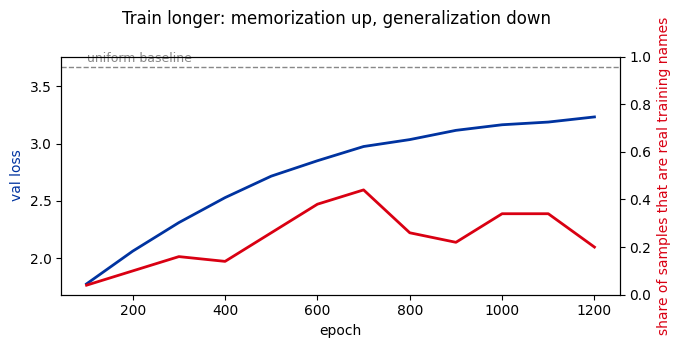

verbatim share: 4% (epoch 100)  ->  20% (epoch 1200)
val loss:       1.777 (epoch 100)  ->  3.232 (epoch 1200)   (uniform baseline 3.664)


In [17]:
# Note: a raw loop on purpose - NO early stopping here. We *want* to watch it overtrain.
torch.manual_seed(SEED)
K = 3
Xtr, Ytr = build_dataset(tr_names, K)
Xva, Yva = build_dataset(va_names, K)
m_long = NameMLP(V, K, 8, 128)
opt = torch.optim.Adam(m_long.parameters(), lr=3e-3)
g = torch.Generator().manual_seed(SEED)

epochs_ax, val_ax, verb_ax = [], [], []
for ep in range(1, 1201):
    idx = torch.randperm(len(Xtr), generator=g)
    for k in range(0, len(idx), 1024):
        b = idx[k:k + 1024]
        loss = F.cross_entropy(m_long(Xtr[b]), Ytr[b])
        opt.zero_grad(); loss.backward(); opt.step()
    if ep % 100 == 0:
        s = sample_names(m_long, K, n=50, seed=SEED + ep)
        epochs_ax.append(ep)
        val_ax.append(evaluate(m_long, Xva, Yva))
        verb_ax.append(sum(x in tr_set for x in s) / 50)

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.plot(epochs_ax, val_ax, color="#0033A0", lw=2)
ax1.axhline(uniform_loss, color="#888888", ls="--", lw=1)
ax1.annotate("uniform baseline", (epochs_ax[0], uniform_loss),
             textcoords="offset points", xytext=(0, 4), color="#888888", fontsize=9)
ax1.set_xlabel("epoch"); ax1.set_ylabel("val loss", color="#0033A0")
ax2 = ax1.twinx()
ax2.plot(epochs_ax, verb_ax, color="#D90012", lw=2)
ax2.set_ylabel("share of samples that are real training names", color="#D90012")
ax2.set_ylim(0, 1)
fig.suptitle("Train longer: memorization up, generalization down")
fig.tight_layout()
plt.show()
print(f"verbatim share: {verb_ax[0]:.0%} (epoch 100)  ->  {verb_ax[-1]:.0%} (epoch 1200)")
print(f"val loss:       {val_ax[0]:.3f} (epoch 100)  ->  {val_ax[-1]:.3f} (epoch 1200)"
      f"   (uniform baseline {uniform_loss:.3f})")

## 11. Bonus: what did the embeddings learn?

Each character became a learned $d$-dim vector. The net was never told about phonetics;
anything phonetic we find, it inferred purely from which characters are statistically
interchangeable inside 689 surnames. Two ways to look, both honest at this scale:

**1. Nearest neighbors in the full 8-D space** — no projection, no artifacts: for each
letter, which letters got the most similar vectors? Look for pairs that *behave* alike in
surnames finding each other — in our runs the near-homophones **ե–է** and **ո–օ** tend to
be mutual neighbors — while the grand vowel/consonant split does not emerge.

**2. PCA to 2D** (ch10 — your own tool) for the overview picture. Why not t-SNE or UMAP,
also ch10? Measured on this machine: UMAP costs *minutes* of import + fit for these 39
points and revealed no extra structure in our pilots. Those tools earn their keep at
thousands of points — ch10's photo map — not dozens; at 39 points, full-space neighbors
beat any 2D squeeze.

Read the result honestly: **no clean vowel/consonant split at this data size** — a
finding, not a failure. In the Bengio (2003) setup, trained on *millions* of words,
exactly this kind of analysis shows crisp clusters. Representation quality is bought with
data — the same lesson the near-tie leaderboard taught, now seen from inside the network.

In [18]:
VOWELS = set("աեէըիոօ")
E = final_model.emb.weight.detach().numpy()
En = E / np.linalg.norm(E, axis=1, keepdims=True)
sim = En @ En.T                                  # cosine similarity, letter x letter

print("nearest neighbors in the full 8-D embedding space:")
for ch in "աեէիոօսնր":
    i = stoi[ch]
    nearest = np.argsort(-sim[i])[1:5]
    print(f"  {ch}:  " + "  ".join(itos[j] for j in nearest))

nearest neighbors in the full 8-D embedding space:
  ա:  ն  ի  զ  ո
  ե:  ք  է  և  ւ
  է:  հ  ճ  ե  ձ
  ի:  ա  ց  ձ  ք
  ո:  գ  ք  ռ  օ
  օ:  ք  և  ս  ո
  ս:  ծ  օ  մ  և
  ն:  ա  ժ  զ  խ
  ր:  ճ  լ  մ  դ


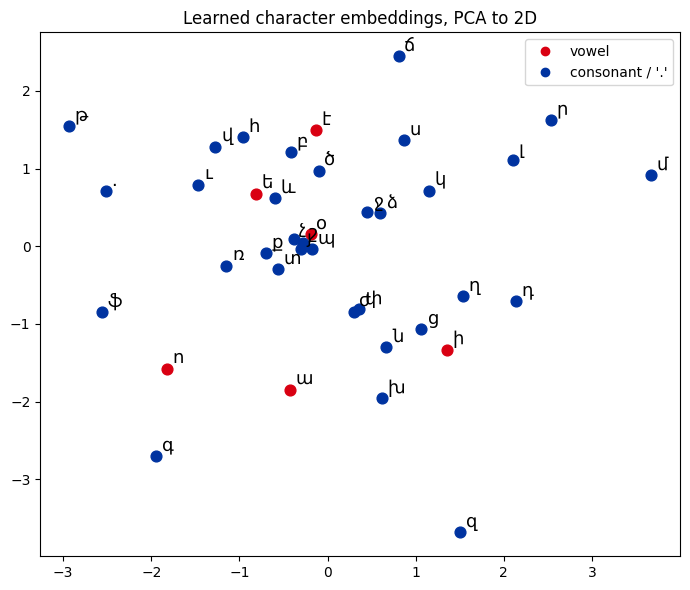

In [19]:
from sklearn.decomposition import PCA

pcs = PCA(n_components=2, random_state=SEED).fit_transform(E)

plt.figure(figsize=(7, 6))
for i in range(V):
    ch = itos[i]
    is_v = ch in VOWELS
    plt.scatter(pcs[i, 0], pcs[i, 1],
                c="#D90012" if is_v else "#0033A0", s=60,
                label=("vowel" if is_v else "consonant") if i < 2 else None)
    plt.annotate(ch, (pcs[i, 0], pcs[i, 1]), fontsize=13,
                 xytext=(4, 4), textcoords="offset points")
from matplotlib.lines import Line2D
plt.legend(handles=[Line2D([], [], marker="o", ls="", color="#D90012", label="vowel"),
                    Line2D([], [], marker="o", ls="", color="#0033A0", label="consonant / '.'")])
plt.title("Learned character embeddings, PCA to 2D")
plt.tight_layout(); plt.show()

## 12. Bonus: steer it — names from your initials

Conditioning, the cheapest way: pre-load the context with characters of your choice and let
the net finish. (The grown-up version of this idea is called *prompting*.)

In [20]:
@torch.no_grad()
def finish(model, K, prefix, n=6, temp=1.0, seed=SEED):
    gen = torch.Generator().manual_seed(seed)
    out = []
    for _ in range(n):
        ctx = ([0] * K + [stoi[c] for c in prefix])[-K:]
        s = prefix
        while True:
            p = F.softmax(model(torch.tensor([ctx])) / temp, dim=1)
            i = int(torch.multinomial(p, 1, generator=gen))
            if i == 0 or len(s) > 25:
                break
            s += itos[i]
            ctx = ctx[1:] + [i]
        out.append(s.capitalize())
    return out

for prefix in ["տ", "քո", "մաշ"]:          # try your own initials here
    print(f"{prefix}...  ->  " + ", ".join(finish(final_model, bestK, prefix)))

տ...  ->  Տեֆրաբուրյան, Տարդիսյան, Տարանյան, Տարյան, Տզոյան, Տաբակիրյան
քո...  ->  Քոյինզարյան, Քոլաջյան, Քողյան, Քոյան, Քոյամյան, Քոլոյան
մաշ...  ->  Մաշյինզարյան, Մաշիիզյան, Մաշայան, Մաշյան, Մաշյան, Մաշյան


## 13. What you actually built

A character-level **language model**: embeddings -> MLP -> softmax over the next token,
trained with cross-entropy. That is Bengio et al. (2003) — the direct ancestor of every
modern LLM. What separates it from ChatGPT is scale and one architectural idea: **much**
more data, a **much** longer context, and *attention* in place of our fixed $K$-window
(a later chapter). The training loop, the loss, the sampling, the temperature knob, the
memorization risk — those you have now seen for real, at surname scale.

And keep the wandb habit: from here on, every experiment in this course is a run with its
config recorded.

**Next:** convolutional networks — what happens when the *input* has shape worth
respecting.